### DSMPC without Terminal Ingredients HALL AND ERDIN

Copyright (C) 2024, Alexander Erdin (aerdin@ethz.ch), ETH Zurich

This project is licensed under the MIT License.

#### Setup

In [1]:
# Reload scripts when executed
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from time import sleep
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from params import DSMPCParams
from systems import LinearSystem
from controllers import EMPC

In [16]:
# Fix random seed and print options
np.random.seed(1)
np.set_printoptions(threshold=10000, linewidth=np.inf)

##### Load Parameters and Create System

In [17]:
params = DSMPCParams()
sys = LinearSystem(params.sys)

Agents: ['27', '142', '387', '1222', '1417', '2096', '2318', '2358', '3000', '3488']


##### Initialize controller

In [18]:
ctrl = EMPC(sys, params.ctrl)

#### Simulate System

In [19]:
# Setup simulation
num_steps = params.sim.num_steps
num_traj = params.sim.num_traj
x_0 = params.sim.x_0

# Allocate state and input trajectories
x = np.zeros((num_traj, num_steps+1, sys.n))
u = np.zeros((num_traj, num_steps,   sys.m))

# Simulate closed-loop system
for i, xi_0 in enumerate(tqdm(x_0, desc='Trajectories')):
    # Set initial state
    x[i,0,:] = xi_0
    for t in tqdm(range(num_steps),desc='     MPC', leave=False):
        # Solve the EMPC problem
        sol_u, sol_x, error_msg = ctrl.solve(x[i,t,:], additional_parameters=t, verbose=False)
        if error_msg != None:
            raise Exception(error_msg)

        # Propagate dynamics and save input
        u[i,t,:]   = sol_u[:,0]
        x[i,t+1,:] = sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,))

        # Some debug information
        # tmp = np.abs(sol_x[:,1] - sys.f(sol_x[:,0], sol_u[:,0], t=t).reshape((sys.n,)))
        # print('At time {0} Dynamics is {1} with diff: {2}'.format(t,np.all(tmp < 1E-5), np.max(tmp)))
        sleep(0.01)

Trajectories:   0%|          | 0/1 [00:00<?, ?it/s]

     MPC:   0%|          | 0/48 [00:00<?, ?it/s]

#### Plot Results

##### Sophie's Plot

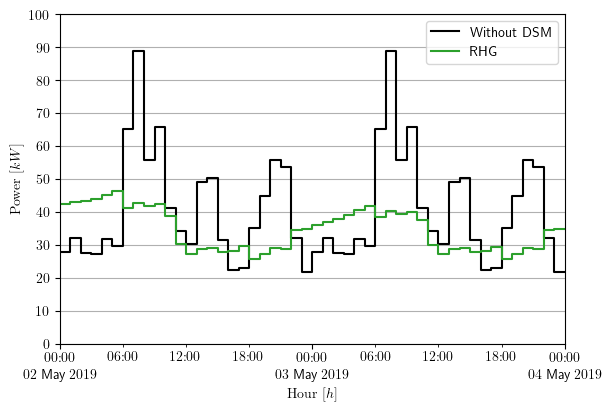

In [17]:
# Set font style
plt.rcParams['text.usetex'] = True

# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]

# Compute passive load without DSM
n_tile = int(num_steps/sys.T)
no_dsm = np.tile(params.ctrl.consumption.sum(axis=1) + params.ctrl.passive_load, n_tile)
no_dsm = np.hstack([no_dsm, no_dsm[-1]])

# Compute aggregate load
agg_load = [u[i,:].sum(axis=1) - np.tile(params.ctrl.solar.sum(axis=1), n_tile) + np.tile(params.ctrl.passive_load, n_tile) for i in range(num_traj)]
agg_load = [np.hstack([agg_load[t], agg_load[t][-1]]) for t in range(num_traj)]

# Create figure
fig, axs = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

# Plot passive load
axs.plot(dates, no_dsm, label='Without DSM', color='black', linestyle='-', drawstyle='steps-post')

# Plot trajectories
for i in range(num_traj):
    axs.plot(dates, agg_load[i], label='RHG' if i == 0 else '_', color='tab:green', linestyle='-', drawstyle='steps-post')

# Add labels
axs.set_xlabel(r'\rmfamily{Hour} $[h]$')
axs.set_ylabel(r'\rmfamily{Power} $[kW]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
axs.xaxis.set_major_locator(mdates.DayLocator(interval=1))
axs.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
axs.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M \\ %d %b %Y'))
axs.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))
axs.yaxis.set_major_locator(ticker.MultipleLocator(base=10, offset=0))

# Set limits
axs.set_xlim([dates[0], dates[-1]])
axs.set_ylim([0, 100])

# Set grid
axs.yaxis.grid(True)
axs.xaxis.grid(False)

# Plot legend
axs.legend(loc='upper right')

# Export figure
# fig.savefig("figures/figure_hall.svg")

##### Turnpike Plots

We decided to plot accumulated states and inputs to demonstrate the turnpike property as we have a multidimensional system containing multiple agents $v$. Hence the accumulated states are a simple sums across all agents given by
\begin{equation}
    \bar{\zeta}_t = \sum_{v \in \mathcal{A}} \zeta_t^v, \qquad \bar{q}_t = \sum_{v \in \mathcal{A}} q_t^v
\end{equation}
with $\bar{x}_t$ being the accumulated state vector. The accumulated inputs $\bar{u}_t$ are defined accordingly.

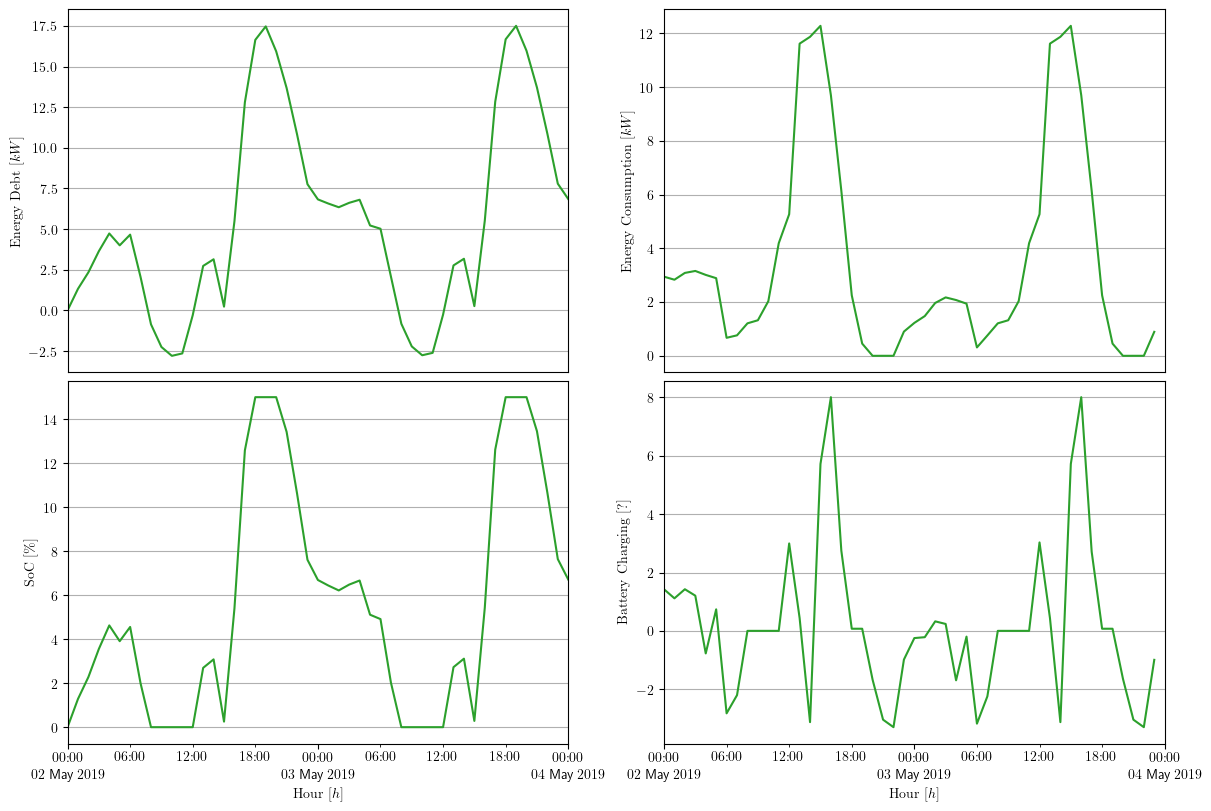

In [56]:
# Create time vector
dates = [params.ctrl.start_date + pd.Timedelta(hours = h) for h in range(num_steps+1)]

# Compute accumulated states
x_acc = np.zeros((num_traj, num_steps+1, 2))
u_acc = np.zeros((num_traj, num_steps, 2))
for i in range(num_traj):
    x_acc[i,:,:] = np.vstack([x[i,:,0:2].sum(axis=1), x[i,:,1:2].sum(axis=1)]).T
    u_acc[i,:,:] = np.vstack([u[i,:,0:2].sum(axis=1), u[i,:,1:2].sum(axis=1)]).T

# Create figure
plt.rcParams['text.usetex'] = True
fig, axs = plt.subplots(2, 2, figsize=(12, 8), layout='constrained')

# Plot trajectories
for i in range(num_traj):
    axs[0][0].plot(dates, x_acc[i,:,0], color='tab:green', linestyle='-')
    axs[1][0].plot(dates, x_acc[i,:,1], color='tab:green', linestyle='-')
    axs[0][1].plot(dates[:-1], u_acc[i,:,0], color='tab:green', linestyle='-')
    axs[1][1].plot(dates[:-1], u_acc[i,:,1], color='tab:green', linestyle='-')

# Add labels
axs[0][0].xaxis.set_visible(False)
axs[0][1].xaxis.set_visible(False)
axs[0][0].set_ylabel(r'\rmfamily{Energy Debt} $[kW]$')
axs[1][0].set_ylabel(r'\rmfamily{SoC} $[\%]$')
axs[0][1].set_ylabel(r'\rmfamily{Energy Consumption} $[kW]$')
axs[1][1].set_ylabel(r'\rmfamily{Battery Charging} $[?]$')
axs[1][0].set_xlabel(r'\rmfamily{Hour} $[h]$')
axs[1][1].set_xlabel(r'\rmfamily{Hour} $[h]$')

# Set major and minor ticks
plt.rcParams['timezone'] = dates[0].tz.zone
for ax in axs[1]:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(r'%H:%M \\ %d %b %Y'))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter(r'%H:%M'))

# Set limits
for ax in axs.flatten():
    ax.set_xlim([dates[0], dates[-1]])
    #ax.set_ylim([0, 100])

    # Set grid
    ax.yaxis.grid(True)
    ax.xaxis.grid(False)

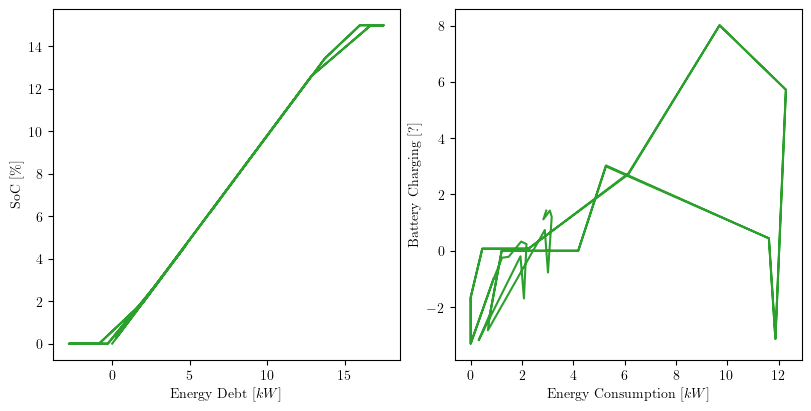

In [55]:
# Create figure
plt.rcParams['text.usetex'] = True
fig, axs = plt.subplots(1, 2, figsize=(8, 4), layout='constrained')

# Plot trajectories
for i in range(num_traj):
    axs[0].plot(x_acc[i,:,0], x_acc[i,:,1], color='tab:green', linestyle='-')
    axs[1].plot(u_acc[i,:,0], u_acc[i,:,1], color='tab:green', linestyle='-')

# Add labels
axs[0].set_xlabel(r'\rmfamily{Energy Debt} $[kW]$')
axs[0].set_ylabel(r'\rmfamily{SoC} $[\%]$')
axs[1].set_xlabel(r'\rmfamily{Energy Consumption} $[kW]$')
axs[1].set_ylabel(r'\rmfamily{Battery Charging} $[?]$');